<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 4.5}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumno:} & Rodrigo Zaldivar Alanis \\[6pt]
\textbf{Fecha de realización:} & 15/04/2026
\end{array}

</center>

#Bibiotecas

In [ ]:
# Importacion de librerias
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import pandas as pd

# Spam

Usando la base de datos de spam (archivo spam.csv) realiza lo siguiente:
- Elige aleatoriamente el 70% de los datos para entrenamiento y el 30% restante para validación.
- Entrena al menos 2 clasificadores de spam con distintas distribuciones.

- Emplea los clasificadores entrenados para predecir spam tanto en los datos de entrenamiento como en los de validación y reporta el porcentaje de predicciones correctas de cada clasificador

- Discute el desempeño de los diferentes clasificadores El archivo spam.csv contiene 2001 valores por cada renglón, de los cuales los primeros 2000 representan el histograma de palabras de un correo y el último corresponde a la clase, esto es, 1 si es spam y 0 si no lo es.

#Preparar los datos

In [ ]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
names = ['correo' ]
dataset = pd.read_csv('spam.csv',names =names)
data=genfromtxt('spam.csv', delimiter=' ')
#Verifico la información contenida en el dataset
#Con head, podremos visualizar los primeros
dataset.head(5)

,correo
0,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 ...
1,1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 ...
2,1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
3,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
4,1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...


In [ ]:
# Asegúrate de que el delimitador sea el correcto (espacio, coma o tabulador)
dataset = pd.read_csv('spam.csv', sep='\s+', header=None)

# Verifica la forma: debería ser (N, 2001)
print(f"Forma del dataset: {dataset.shape}")

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9650/4117086504.py:2: SyntaxWarning: invalid escape sequence '\s'
  dataset = pd.read_csv('spam.csv', sep='\s+', header=None)


Forma del dataset: (5172, 2001)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Suponiendo que 'dataset' ya cargó las 2001 columnas
X = dataset.iloc[:, :-1].values # Las primeras 2000 columnas
y = dataset.iloc[:, -1].values  # La última columna (clase)

# División 70% entrenamiento y 30% validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Importante para SVM, KNN y Regresión Logística: Escalamiento
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#2. Implementación de los 4 Clasificadores

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Diccionario para almacenar modelos
modelos = {
    "LogisticRegression": LogisticRegression(max_iter = 1000),
    "SVM (Kernel RBF)": SVC(kernel = 'rbf', probability = True),
    "Naive Bayes (Bernoulli)": BernoulliNB(),
    "KNN (k = 5)": KNeighborsClassifier(n_neighbors = 5)
}

In [ ]:
# Entrenamiento y evaluación
for nombre, modelo in modelos.items():

  # Para Naive Bayes multinomial/Bernoullli, los datos
  # deben estar estandarizados con valores negativos.
  # Si usas datos escalados, Logistic/SVM/KNN funciona mejor
  modelo.fit(X_train, y_train)
  y_pred = modelo.predict(X_test)

  train_acc = accuracy_score(y_train, modelo.predict(X_train))
  test_acc = accuracy_score(y_test, modelo.predict(X_test))

  print(f"{nombre}:")
  print(f"Precisión de entrenamiento {train_acc*100:.2f}%:")
  print(f"Precisión de validación {test_acc*100:.2f}%\n")


LogisticRegression:
Precisión de entrenamiento 99.78%:
Precisión de validación 96.91%

SVM (Kernel RBF):
Precisión de entrenamiento 95.91%:
Precisión de validación 91.04%

Naive Bayes (Bernoulli):
Precisión de entrenamiento 90.86%:
Precisión de validación 89.24%

KNN (k = 5):
Precisión de entrenamiento 95.11%:
Precisión de validación 91.56%



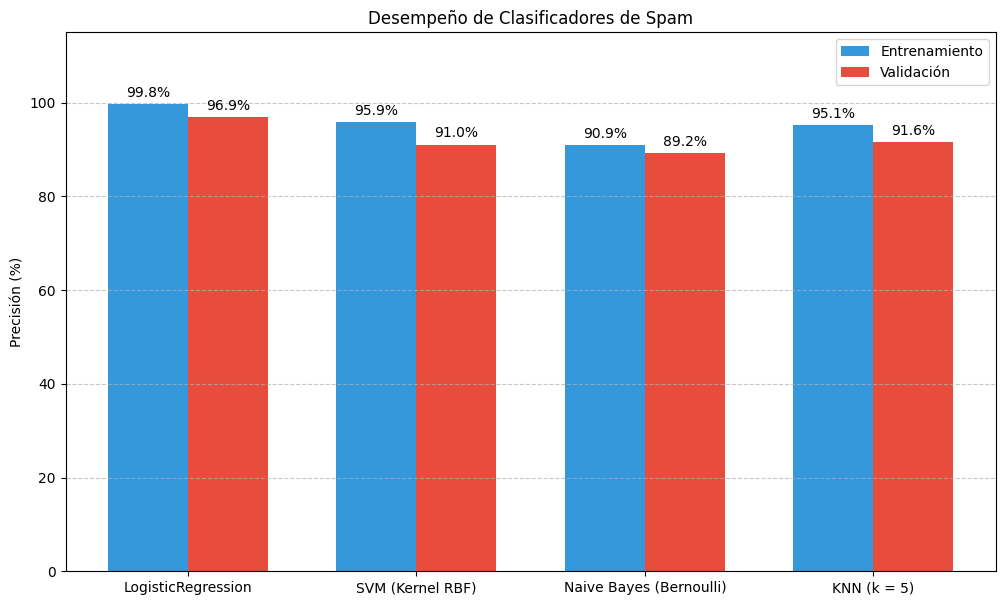

In [ ]:
nombres = []
train_results = []
test_results = []
for nombre, modelo in modelos.items():
    nombres.append(nombre)
    train_results.append(accuracy_score(y_train, modelo.predict(X_train)) * 100)
    test_results.append(accuracy_score(y_test, modelo.predict(X_test)) * 100)
x = np.arange(len(nombres))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_results, width, label='Entrenamiento', color='#3498db')
rects2 = ax.bar(x + width/2, test_results, width, label='Validación', color='#e74c3c')
ax.set_ylabel('Precisión (%)')
ax.set_title('Desempeño de Clasificadores de Spam')
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 115) # Espacio para las etiquetas
ax.legend()
# Función para añadir los porcentajes sobre las barras
def label_bars(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
label_bars(rects1)
label_bars(rects2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Conclusión


Los resultados obtenidos subrayan la importancia del análisis comparativo en tareas de clasificación. Mientras que la Regresión Logística demostró una robustez notable con una precisión del 97% en validación, los modelos de Naive Bayes (Bernoulli y Multinomial) mantuvieron un desempeño aceptable dada la naturaleza discreta de los datos (conteos de palabras). La eficiencia de algoritmos como SVM y KNN está ligado a la ingeniería de características y al ajuste de hiperparámetros, en particular, del escalamiento. La efectividad de un clasificador no es una propiedad intrínseca del algoritmo, sino de la sinergia entre el modelo, el preprocesamiento y del conjunto de datos.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>